In [ ]:
# Kingston PM2.5 concentrations

## Import modules

In [1]:
import pandas as pd
import geopandas as gpd
import folium
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [32]:
fname_grid = "LAEI2019_grid.shp"

In [33]:
grid = gpd.read_file(fname_grid)

,Grid_ID_19,GridIdEx,1km2_ID,Easting,Northing,Area_km2,Borough,Zone,geometry
0,1,1,5910,510500,203500,1.0,NonGLA,NonGLA,"POLYGON ((511000.001 203000.001, 509999.999 20..."
1,2,2,5911,511500,203500,1.0,NonGLA,NonGLA,"POLYGON ((512000.003 203000.001, 511000.001 20..."
2,3,3,5912,512500,203500,1.0,NonGLA,NonGLA,"POLYGON ((512999.997 203000.001, 512000.003 20..."
3,4,4,5915,515500,203500,1.0,NonGLA,NonGLA,"POLYGON ((516000.004 203000.001, 515000.002 20..."
4,5,5,5916,516500,203500,1.0,NonGLA,NonGLA,"POLYGON ((516999.998 203000.001, 516000.004 20..."


## Read in PM 2.5 concentrations data

High data resolution: 20 metre x 20 metre squares
Circa 6 million rows of data

In [11]:
chunks = range(1, 12)

# read in first chunk
df = pd.read_csv("LAEI2022_V1_PM25_chunk_0.csv")

# append remaining chunks
for c in chunks:
    add_df = pd.read_csv(f"LAEI2022_V1_PM25_chunk_{c}.csv")
    df = pd.concat([df, add_df])

,x,y,conc
0,519100,203440,7.892006
1,519120,203440,7.993147
2,519140,203440,8.219271
3,519160,203440,8.054134
4,519180,203440,7.904491


In [13]:
df = df.rename(columns={"x": "Easting", "y": "Northing"})

In [20]:
# even this dataset of extreme values contains circa 59,000 rows and has lots of outliers
percentile_99 = df[df["conc"] > np.percentile(df["conc"], 99)]

(58520, 3)

## Spatial join the concentrations data to the LAEI 2019 (1 km x 1 km) grid squares

This maps each 20 metre grid square to a London borough.

In [70]:
gdf = gpd.GeoDataFrame(percentile_99, 
                        geometry=gpd.points_from_xy(percentile_99["Easting"], percentile_99["Northing"]),
                        crs="EPSG:27700")

gdf = gdf.sjoin(grid, how="left", predicate="within")

## Number of squares in the 99th percentile (by London borough)

Focus on the top 10 boroughs.

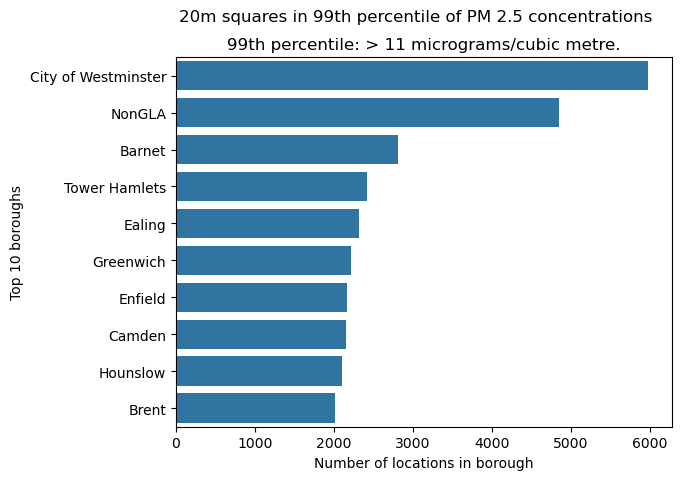

In [57]:
sns.barplot(data=gdf["Borough"].value_counts()[:10], orient="h")
plt.suptitle("20m squares in 99th percentile of PM 2.5 concentrations")
plt.title("One point = 20m x 20m square.")
plt.title("99th percentile: > 11 micrograms/cubic metre.")
plt.xlabel("Number of locations in borough")
plt.ylabel("Top 10 boroughs")
plt.show()

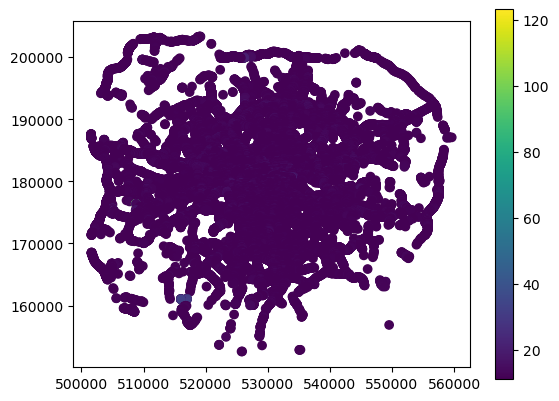

In [59]:
gdf.plot(column="conc", legend=True)
plt.show()

## FixMe (20260222)

* Figure out how to apply the key_on argument correctly (particular id values, NoneType objects)
* Consider calculating the median PM 2.5 (annual average) concentration for each LAEI 2019 grid square and plotting a choropleth map of LAEI 2019 grid squares

In [73]:
# london_centre = [51.51, -0.12]

# m = folium.Map(location=london_centre, zoom_start=10)

# folium.Choropleth(
#     geo_data=gdf,
#     name="PM2.5_99thPercentile",
#     data=gdf,
#     columns=["1km2_ID", "conc"],
#     key_on="features.properties.1km2_ID",
#     fill_color="viridis",
#     legend_name="PM 2.5 concentration (micrograms/cubic metre)",
# ).add_to(m)

# folium.LayerControl().add_to(m)

m

AttributeError: 'NoneType' object has no attribute 'get'